In [1]:
from datetime import datetime
from pathlib import Path
from typing import Optional, Tuple, Dict

#from data.minbpe import BasicTokenizer as Tokenizer
from src.minbpe import RegexTokenizer as Tokenizer
from src.gpt import GPTLanguageModel

import matplotlib.pyplot as plt
import torch
torch.manual_seed(3647)
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

def print_model_structure(model: nn.Module, indent: str = '') -> None:
    """
    Custom function to print model structure in a hierarchical format
    """
    for name, child in model.named_children():
        params = sum(p.numel() for p in child.parameters())
        print(f"{indent}├─ {name}: {child.__class__.__name__} ({params:,} parameters)")
        print_model_structure(child, indent + '│  ')

In [3]:
####
output_dir = Path("data") / "tokenizer"

tokenizer = Tokenizer()
tokenizer.load(model_file=str(output_dir / "tokenizer.model"))

train_data = torch.load(output_dir / 'train.tokens.pt')
val_data = torch.load(output_dir / 'validation.tokens.pt')

print(f"--> train_data: {train_data.size()[0]:_}, val_data: {val_data.size()[0]:_}")

--> train_data: 8_331_538, val_data: 429_547


In [4]:
checkpoint_dir = Path("data") / "ch02_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

#### model parameters
block_size = 256
n_embd = 512
n_head = 8
n_layer = 4
dropout = 0.2
vocab_size = len(tokenizer.vocab) + len(tokenizer.special_tokens)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

#### training parameters
max_iters = 2
learning_rate = 3e-4
batch_size = 32 # 64
eval_interval = 100
eval_iters = 200

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device,
).to(device)

model = torch.compile(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')

print_model_structure(model)

--> 13.8M parameters
├─ _orig_mod: GPTLanguageModel (13,795,338 parameters)
│  ├─ token_embedding_table: Embedding (529,408 parameters)
│  ├─ position_embedding_table: Embedding (131,072 parameters)
│  ├─ blocks: Sequential (12,603,392 parameters)
│  │  ├─ 0: Block (3,150,848 parameters)
│  │  │  ├─ self_attention: MultiHeadAttention (1,049,088 parameters)
│  │  │  │  ├─ heads: ModuleList (786,432 parameters)
│  │  │  │  │  ├─ 0: Head (98,304 parameters)
│  │  │  │  │  │  ├─ key: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ query: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ value: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ dropout: Dropout (0 parameters)
│  │  │  │  │  ├─ 1: Head (98,304 parameters)
│  │  │  │  │  │  ├─ key: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ query: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ value: Linear (32,768 parameters)
│  │  │  │  │  │  ├─ dropout: Dropout (0 parameters)
│  │  │  │  │  ├─ 2: Head (98,304 parameters)
│  │  │  │  │  │ 

In [5]:
class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index:index + self.block_size]
        y = self.data[index + 1:index + self.block_size + 1]
        return x, y

def get_dataloaders(
        train_data: torch.Tensor,
        val_data: torch.Tensor,
        block_size: int,
        batch_size: int,
        device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

@torch.no_grad()
def estimate_loss(
    model: torch.nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    eval_iters: int,
) -> Dict[str, float]:
    output = {}
    model.eval() # 评估模式

    for split, loader in [('train', train_loader), ('val', val_loader)]:
        losses = torch.zeros(eval_iters)
        for i, (x, y) in enumerate(loader):
            if i >= eval_iters:
                break

            with torch.no_grad():
                _, loss = model(x, y) # 前向传播（Forward Pass）
            losses[i] = loss.item()
        output[split] = losses.mean().item()

    model.train() # 切换到为推理
    return output

In [7]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=block_size,
    batch_size=batch_size,
    device=device,
)

train_losses, val_losses = [], []

for iteration in range(1, max_iters+1):
    # train_data.shape[0]/batch_size = 260.36k, 
    # train_loader = data[N, 2, batch_size, block_size]
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        # Evaluation
        batch_n = batch_idx + 1
        if batch_n % eval_interval == 0 or batch_n == len(train_loader):
            losses = estimate_loss(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                eval_iters=min(eval_iters, len(val_loader)),
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            print("{} iteration={:03}, step={:07_}, train_loss={:.3f}, val_loss={:.3f}".format(
                now(), iteration, batch_n, losses['train'], losses['val'],
            ))

        # Training step
        logits, loss = model(x_batch, y_batch)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    # Save checkpoint
    checkpoint_pt = str(checkpoint_dir / f"checkpoint_{iteration:03d}.pt")

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': iteration,
        'loss': loss.item(),
        'created_at': now(),
    }

    torch.save(checkpoint, checkpoint_pt)
    print(f"{now()} --> saved checkpoint: {checkpoint_pt}")

/home/hello/apps/llm01/.venv/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:236: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0825 16:37:04.983000 53130 torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode


2025-08-25T16:37:46+08:00 iteration=001, step=000_100, train_loss=5.049, val_loss=5.002
2025-08-25T16:38:08+08:00 iteration=001, step=000_200, train_loss=4.398, val_loss=4.327
2025-08-25T16:38:31+08:00 iteration=001, step=000_300, train_loss=4.223, val_loss=4.141
2025-08-25T16:38:53+08:00 iteration=001, step=000_400, train_loss=4.120, val_loss=4.087


KeyboardInterrupt: 

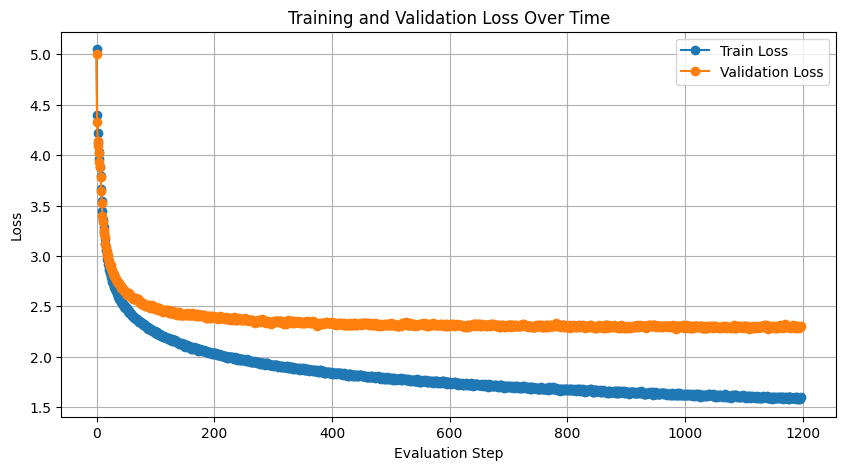

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()
# 2025-08-24T08:37:24+08:00 iteration=001, step=119_800, train_loss=1.606, val_loss=2.304